In [ ]:
import sys
!{sys.executable} -m pip install seaborn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os
from matplotlib.ticker import FuncFormatter
import matplotlib.gridspec as gridspec

In [2]:
from azureml.core import Workspace, Datastore, Dataset

# Kết nối tới workspace (sử dụng file config.json hoặc môi trường đã gắn)
ws = Workspace.from_config()

# Lấy datastore đã có sẵn
datastore = Datastore.get(ws, datastore_name="workspace_storageaccount")

In [3]:
# ====================== CONFIG & STYLE ======================
plt.style.use('default')

CORAL = '#F0997B'
TEAL = '#5DCAA5'
PURPLE = '#7F77DD'
BLUE = '#85B7EB'
AMBER = '#EF9F27'
GREEN = '#97C459'
GRAY = '#B4B2A9'
BG = '#F8F8F6'
DARK = '#3d3d3a'

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': BG,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#E0DED8',
    'grid.linewidth': 0.5,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelcolor': DARK,
    'xtick.color': DARK,
    'ytick.color': DARK,
})

def fmt_millions(x, _):
    """Format số lớn: 1.2M, 450K, ..."""
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    if x >= 1_000:
        return f'{x/1_000:.0f}K'
    return str(int(x))

**<h4>geo_params</h4>**
- Bảng geo_params thể hiện ánh xạ giữa các vùng (cluster) đến thành phố (city ID) tương ứng.  
- Trong đó, có 3 thành phố là 0, 1, 25. Thành phố số 0 có nhiều phân vùng quan sát nhất với 450 cluster, tiếp theo là thành phố 1 với 64 cluster và thành phố 25 chỉ có 1 cluster.
- Dữ liệu tập trung quan sát tại 1 thành phố lớn với nhiều cửa hàng.

In [9]:
geo_df = Dataset.Tabular.from_delimited_files(path=(datastore, "geo_params.csv")).to_pandas_dataframe()
print(geo_df)

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
     geoCluster  cityId
0            21       1
1            47       1
2            48       1
3            92       1
4           112       1
..          ...     ...
510        3182       0
511        3183       0
512        3196       0
513        3209       0
514        3230       0

[515 rows x 2 columns]


In [10]:
print(geo_df.info())
print("\nSố geoCluster unique:", geo_df['geoCluster'].nunique())
print("Các cityId:", sorted(geo_df['cityId'].unique()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   geoCluster  515 non-null    int64
 1   cityId      515 non-null    int64
dtypes: int64(2)
memory usage: 8.2 KB
None

Số geoCluster unique: 515
Các cityId: [0, 1, 25]


In [11]:
# Số geoCluster theo city
result = (geo_df.groupby("cityId")["geoCluster"]
          .nunique()
          .reset_index(name="num_geoCluster"))
print(result)

   cityId  num_geoCluster
0       0             450
1       1              64
2      25               1


In [12]:
del geo_df, result
gc.collect()

3537

**<h4>sku_final</h4>**

- Bảng metadata chính, chứa thông tin về các sản phẩm. Thông tin các thuộc tính:
    - SKU (Stock Keeping Unit): mã định danh của sản phẩm.
    - Commodity_group: nhóm mặt hàng gồm cheeses, tropical fruits, mineral water, yoghurts and bakery.
    - Product type, category: phân loại, danh mục sản phẩm.
    - Origin: Xuất xứ
    - brand, trademark: nhà sản xuất, brand là tập đoàn lớn hơn, trademark là nhãn hiệu con của brand.
    - lagerUnitQuantity: số lượng sản phẩm / 1 đơn vị đóng gói.
    - lagerUnitType: loại đơn vị đóng gói.
    - Các trường caption là tên tương ứng với Id, sẵn sàng trong 3 ngôn ngữ UKR, RU, ENG trừ unit type.
- Các cột đều mang tính định danh, ngoại trừ lagerUnit có tính định lượng.

In [14]:
sku_df = Dataset.Tabular.from_delimited_files(path=(datastore, "sku_final.csv")).to_pandas_dataframe()
print(sku_df)

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
         SKU  productCategoryId productCategory_caption_UKR  \
0         17             5416.0                       Хурма   
1         18             5413.0                      Фейхоа   
2         24             5425.0                      Гранат   
3         25             5431.0                    Апельсин   
4        208             5835.0       Вода України газована   
...      ...                ...                         ...   
1956  873803             5923.0                     Йогурти   
1957  873804             5922.0             Десерти молочні   
1958  873805             5922.0             Десерти молочні   
1959  874108             5922.0             Десерти молочні   
1960  874109             5922.0             Десерти молочні   

     productCategory_caption_RU productCategory_caption_ENG  productTypeId  

In [15]:
# Kiểm tra thông tin thống kê.
print(sku_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1961 entries, 0 to 1960
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SKU                          1961 non-null   int64  
 1   productCategoryId            1961 non-null   float64
 2   productCategory_caption_UKR  1807 non-null   object 
 3   productCategory_caption_RU   1961 non-null   object 
 4   productCategory_caption_ENG  1807 non-null   object 
 5   productTypeId                1744 non-null   float64
 6   productType_caption_UKR      1563 non-null   object 
 7   productType_caption_RU       1744 non-null   object 
 8   productType_caption_ENG      1563 non-null   object 
 9   brandId                      1116 non-null   float64
 10  lagerUnitQuantity            1961 non-null   float64
 11  lagerUnitTypeId              1961 non-null   int64  
 12  lagerUnitType_caption        1961 non-null   object 
 13  trademark         

In [16]:
lookup_dict = dict(
    sku_df[['commodity_group', 'commodity_group_caption_ENG']]
    .drop_duplicates()
    .values
)

print(lookup_dict)

{5551018: 'Tropical fruits', 5550022: 'Mineral water', 5550352: 'Cheese', 5550259: 'Yogurts', 5550412: 'Bakery'}


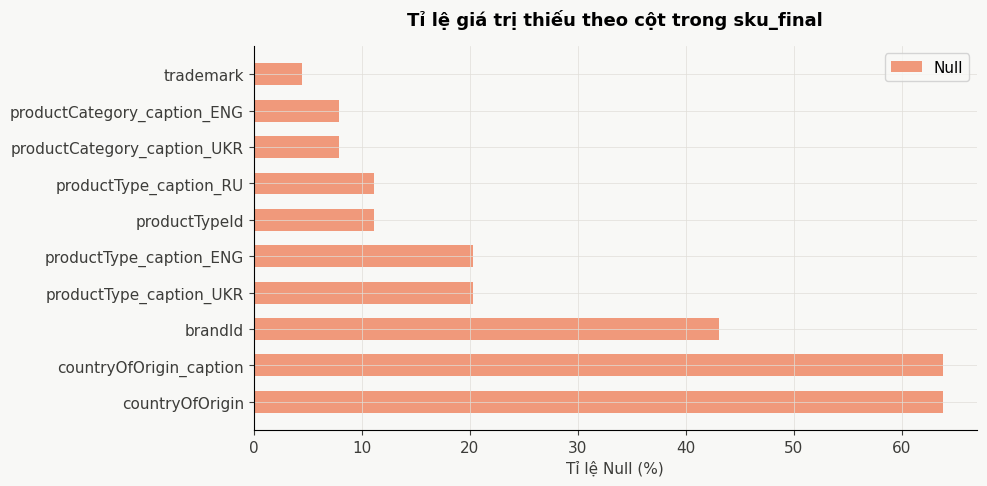

In [17]:
# Null analysis
null_df = (
    pd.DataFrame({
        'null_count': sku_df.isnull().sum(),
        'null_pct': (sku_df.isnull().sum() / len(sku_df) * 100).round(1)
    })
    .query('null_count > 0')
    .sort_values('null_pct', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
y = range(len(null_df))
ax.barh(y, null_df['null_pct'], color=CORAL, height=0.6, label='Null')
ax.set_yticks(y)
ax.set_yticklabels(null_df.index)
ax.set_xlabel('Tỉ lệ Null (%)')
ax.set_title('Tỉ lệ giá trị thiếu theo cột trong sku_final', pad=15)
ax.legend()
plt.tight_layout()
plt.show()

**Nhận xét:**
- countryOfOrigin bị thiếu nhiều nhất -> nhiều sản phẩm không rõ xuất xứ.
- BrandID bị khuyết nhiều hơn so với trademark -> có thể dùng trademark để biết đơn vị cung cấp sản phẩm là đủ.
- ProductTypeID bị thiếu trong khi ProductCategoryID đủ hoàn toàn -> 1 số sản phẩm không được phân cấp rõ ràng.
- Các cột quan trọng chứa thông tin chính như SKU, commodityGroup, lagerUnit, ProductCategoryID đều đủ, đảm bảo lượng thông tin cơ bản.
- Các cột caption thường nhiều hơn ở tiếng Nga (RU), caption tiếng UKR và ENG xuất hiện cùng lúc.  
**Gợi ý:**
- countryOfOrigin và brand có thể bỏ vì thiếu quá nhiều, sử dụng trademark có thể biểu diễn phần nào thông tin của 2 biến này.
- Chỉ giữ lại 1 ngôn ngữ caption để phân tích. Tuy nhiên khi mô hình hóa nên bỏ hết để giảm khối lượng dữ liệu tính toán, thông tin đã được biểu diễn qua cột ID tương ứng rồi.
- Nên giữ lại và điền TypeID theo CategoryID và commodityGroup nếu muốn mô hình chi tiết, hoặc bỏ để tăng tính tổng quát.

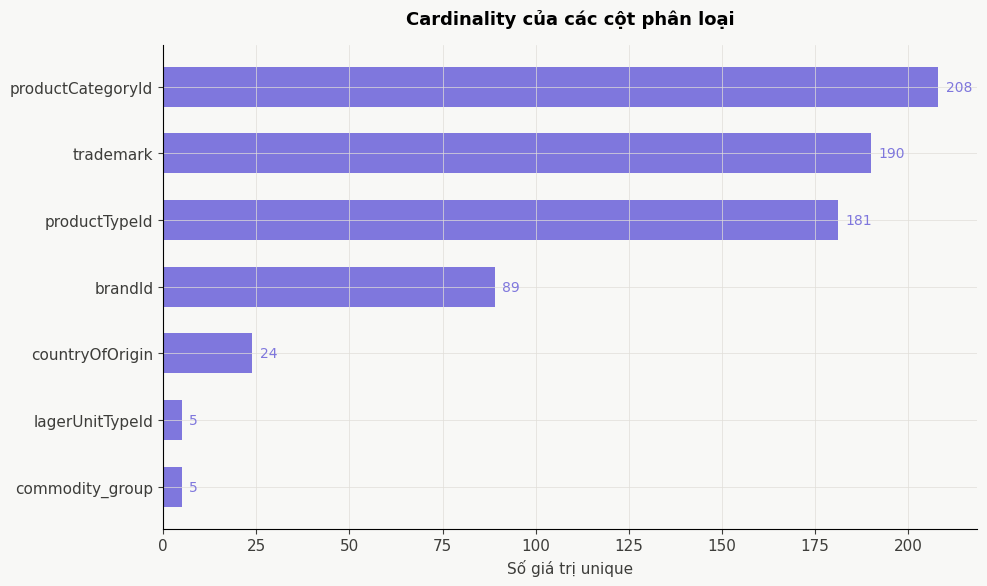

In [18]:
# Cardinality của các cột category
cat_cols = ['productCategoryId', 'productTypeId', 'brandId', 'trademark',
            'commodity_group', 'lagerUnitTypeId', 'countryOfOrigin']

card = {c: sku_df[c].nunique() for c in cat_cols if c in sku_df.columns}
card_s = pd.Series(card).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(card_s.index, card_s.values, color=PURPLE, height=0.6)
for bar, val in zip(bars, card_s.values):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2, str(val),
            va='center', fontsize=10, color=PURPLE)
ax.set_xlabel('Số giá trị unique')
ax.set_title('Cardinality của các cột phân loại', pad=15)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Có nhiều danh mục sản phẩm (Cat) hơn là phân loại sản phẩm (Type) -> Type có thể lớn rộng hơn Cat nhưng có thể là do missing data của Type nhiều hơn Cat.
- Trademark chi tiết hơn brandID do là nhãn hiệu con của thương hiệu.
- Chỉ có 5 nhóm commodity_group và UnitType.
  
**Gợi ý:**
- Có thể dùng one-hot encoding cho commodity và unit.
- Với trademark nên dùng target encoding vì có thể lượng mua sẽ nhiều hơn tùy từng nhãn hàng.
- Với productType và productCat, cũng có thể dùng target encoding vì có thể sẽ có 1 số loại sản phẩm được mua nhiều hơn các loại khác.

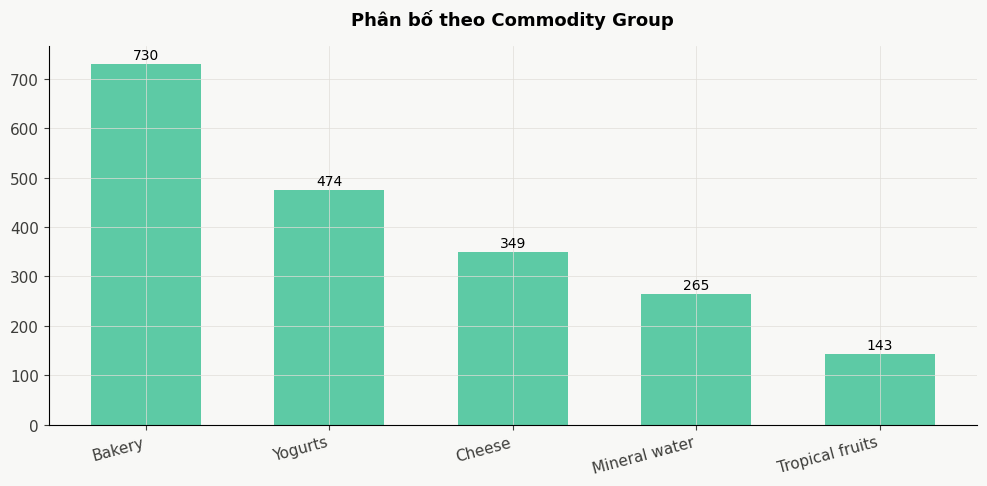

In [19]:
# Phân bố commodity_group
comm = sku_df['commodity_group_caption_ENG'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(comm.index, comm.values, color=TEAL, width=0.6)
for bar, val in zip(bars, comm.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 10, str(val),
            ha='center', fontsize=10)
ax.set_title('Phân bố theo Commodity Group', pad=15)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

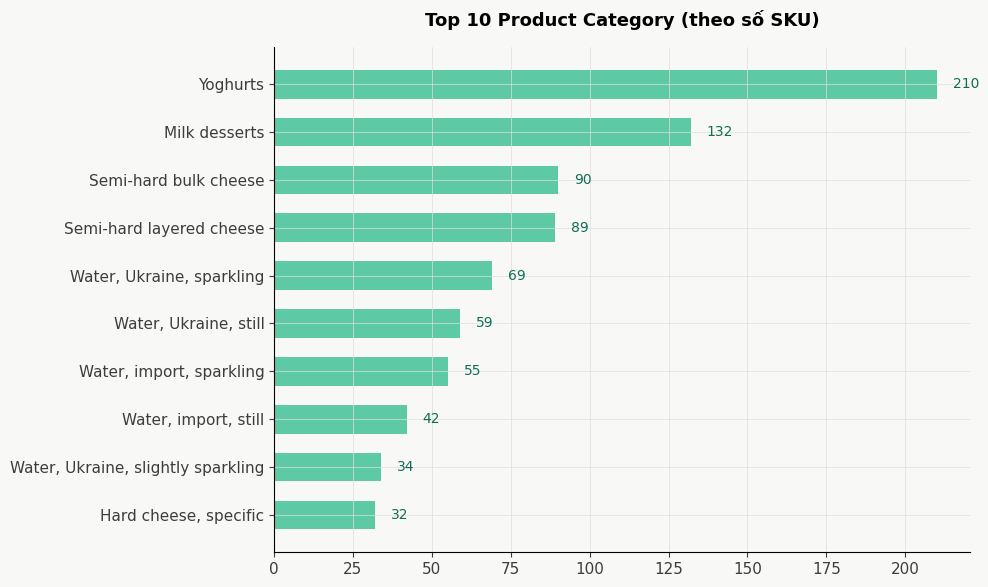

In [20]:
# Top 10 product category
top_cat = sku_df['productCategory_caption_ENG'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_cat.index[::-1], top_cat.values[::-1], color=TEAL, height=0.6)  # reverse để top ở trên
for bar, val in zip(bars, top_cat.values[::-1]):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val),
            va='center', fontsize=10, color='#0F6E56')
ax.set_title('Top 10 Product Category (theo số SKU)', pad=15)
plt.tight_layout()
plt.show()

**Nhận xét:**
- Dữ liệu phân bố không đều giữa các nhóm commodity, Bakery chứa nhiều sản phẩm nhất, tiếp theo là Yogurts và Cheese.
- Tương tự như commodity, Yoghurts và dessert, cheese cũng chiếm ưu thế.
  
**Gợi ý:**
- Có thể huấn luyện riêng model cho từng commodity_group hoặc có chiến thuật cân bằng dữ liệu.
- Cẩn thận khi split dữ liệu.

In [21]:
del sku_df, null_df, card, card_s, comm, top_cat
gc.collect()

13148

**<h4>train_final</h4>**
- Bảng dữ liệu chính với tổng kích thước hơn 1.2GB, chứa thông tin về lượng bán hàng ngày, gồm các cột:
    - ID: mã định danh của quan sát, đại diện cho mỗi dòng dữ liệu.
    - geoCluster: mã cửa hàng.
    - SKU: mã sản phẩm tương ứng.
    - date: ngày tiến hành đo đạc.
    - sales: doanh số bán ra của sản phẩm trong ngày.

In [22]:
train_df = Dataset.Tabular.from_delimited_files(path=(datastore, "train_final.csv")).to_pandas_dataframe()
print(train_df.head(5))

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
           ID  geoCluster    SKU       date  price  sales
0  RR27956447          21  32485 2021-07-08  39.69    0.9
1  RR27956448          21  32485 2021-07-09    NaN    NaN
2  RR27956449          21  32485 2021-07-10    NaN    NaN
3  RR27956450          21  32485 2021-07-11    NaN    NaN
4  RR27956451          21  32485 2021-07-12    NaN    NaN


In [23]:
train_df['date'] = pd.to_datetime(train_df['date'])
train_df['dow'] = train_df['date'].dt.dayofweek   # 0=Thứ 2, 6=Chủ Nhật

In [24]:
print(train_df.info())
print(f"Date range: {train_df['date'].min()} → {train_df['date'].max()}")
print(f"Số ngày: {train_df['date'].nunique()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27956445 entries, 0 to 27956444
Data columns (total 7 columns):
 #   Column      Dtype         
---  ------      -----         
 0   ID          object        
 1   geoCluster  int64         
 2   SKU         int64         
 3   date        datetime64[ns]
 4   price       float64       
 5   sales       float64       
 6   dow         int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(1)
memory usage: 1.5+ GB
None
Date range: 2020-01-01 00:00:00 → 2021-07-19 00:00:00
Số ngày: 566


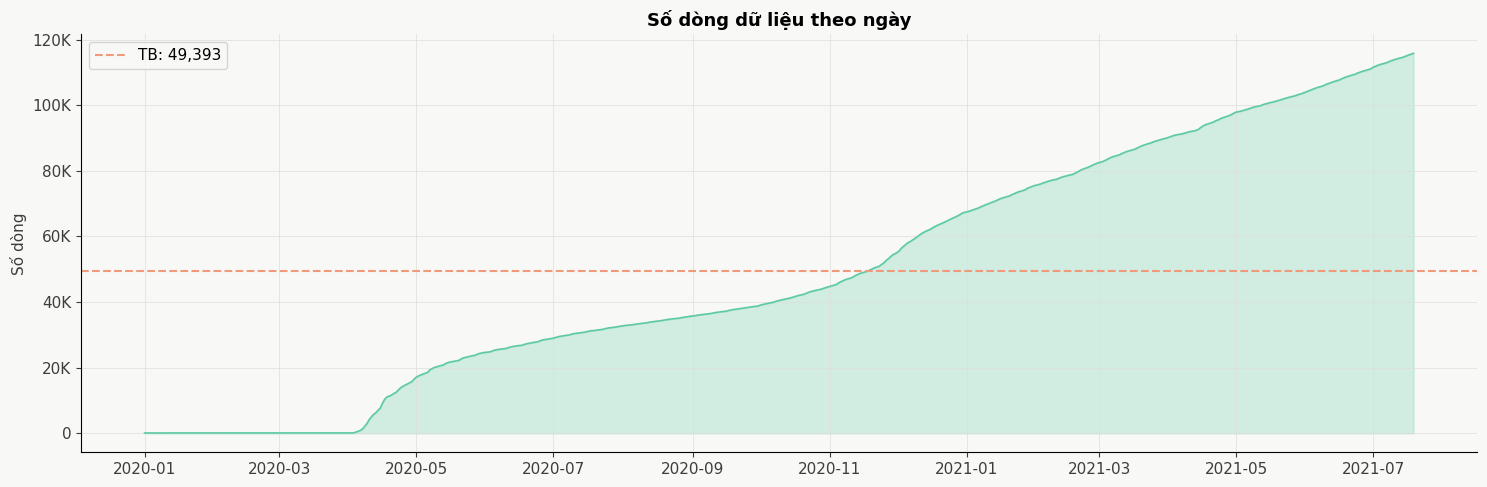

In [25]:
# 1. Số dòng theo ngày
rows_by_date = df = train_df.groupby('date').size()

fig, ax = plt.subplots(figsize=(15, 5))
ax.fill_between(rows_by_date.index, rows_by_date.values, color=TEAL, alpha=0.25)
ax.plot(rows_by_date.index, rows_by_date.values, color=TEAL, linewidth=1.2)
ax.axhline(rows_by_date.mean(), color=CORAL, linestyle='--', label=f'TB: {rows_by_date.mean():,.0f}')
ax.set_title('Số dòng dữ liệu theo ngày')
ax.set_ylabel('Số dòng')
ax.yaxis.set_major_formatter(FuncFormatter(fmt_millions))
ax.legend()
plt.tight_layout()
plt.show()

**Nhận xét:**
- Số dòng dữ liệu theo ngày tăng dẫn theo thời gian.
- Vào giai đoạn đầu của quan sát có rất ít sản phẩm và cửa hàng lưu thông tin bán ra. Nhưng càng về sau, càng nhiều dữ liệu được ghi nhận.

**Gợi ý:**
- Có thể bỏ dữ liệu trước tháng 5/2020.

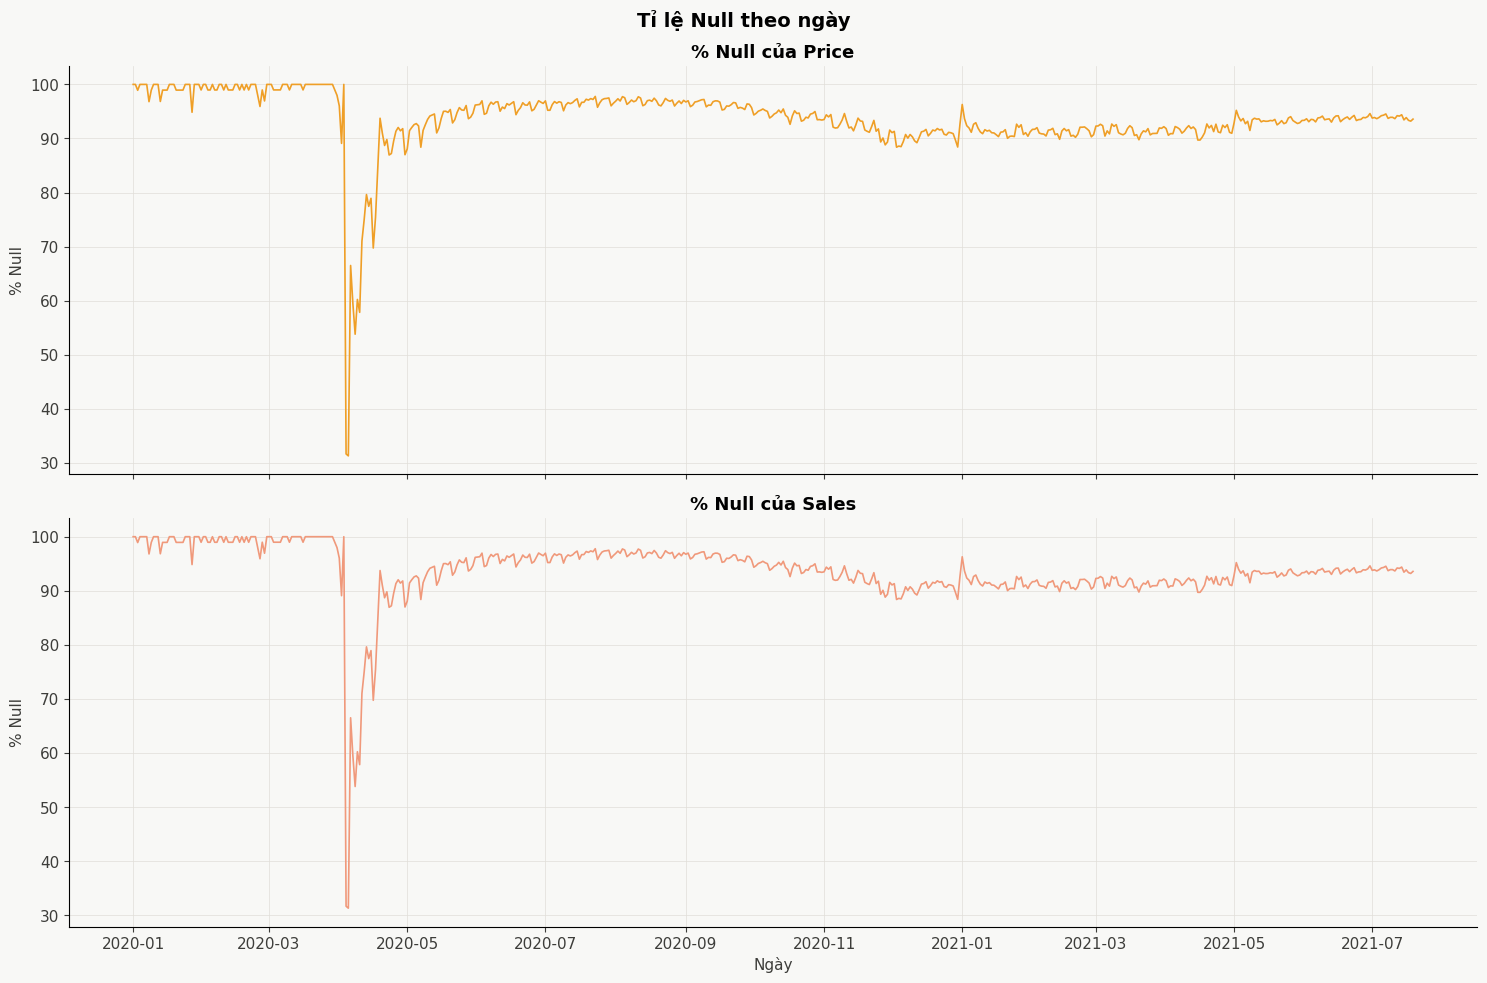

In [26]:
# 2. Tỉ lệ null của price & sales theo ngày
null_price = train_df.groupby('date')['price'].apply(lambda x: x.isnull().mean() * 100)
null_sales = train_df.groupby('date')['sales'].apply(lambda x: x.isnull().mean() * 100)

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
fig.suptitle('Tỉ lệ Null theo ngày', fontsize=14, fontweight='bold')

axes[0].plot(null_price.index, null_price.values, color=AMBER, linewidth=1.2)
axes[0].set_title('% Null của Price')
axes[0].set_ylabel('% Null')

axes[1].plot(null_sales.index, null_sales.values, color=CORAL, linewidth=1.2)
axes[1].set_title('% Null của Sales')
axes[1].set_ylabel('% Null')
axes[1].set_xlabel('Ngày')

plt.tight_layout()
plt.show()

**Nhận xét:**
- Cả price và sales đều có pattern null giống nhau theo thời gian -> đồng bộ theo dòng.
- Đa số thời gian đều có rất nhiều dữ liệu bị khuyết.
- Tỉ lệ null tổng thể rất cao (~92%).

**Gợi ý:**
- Null trong sales chỉ đơn giản là doanh số không được ghi nhận chứ không phải bán ra bằng 0 -> điền khuyết theo pattern, không điền 0.

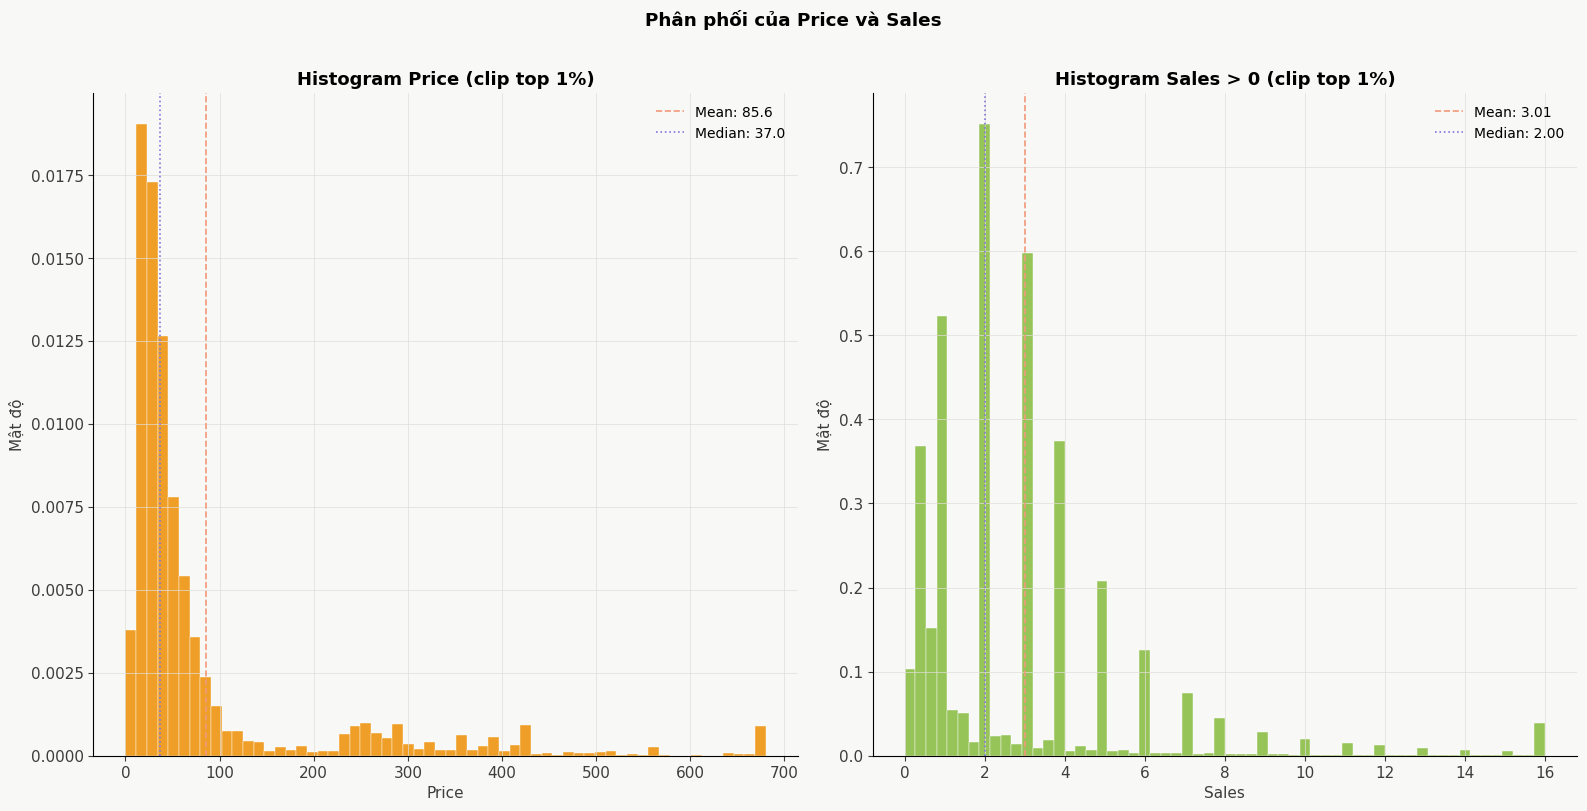

In [27]:
# 3. Phân phối của Price và Sales (Histogram) 

sales_nonzero = train_df.loc[train_df['sales'] > 0, 'sales'].dropna()
price_valid = train_df['price'].dropna()

# Clip outliers ở mức 99th percentile để biểu đồ rõ ràng hơn
sales_clipped = sales_nonzero.clip(upper=sales_nonzero.quantile(0.99))
price_clipped = price_valid.clip(upper=price_valid.quantile(0.99))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Phân phối của Price và Sales', fontweight='bold', y=1.01)

# Histogram Price
axes[0].hist(price_clipped, bins=60, color=AMBER,
             edgecolor='white', linewidth=0.3, density=True)
axes[0].set_title('Histogram Price (clip top 1%)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Mật độ')

mu, med = price_valid.mean(), price_valid.median()
axes[0].axvline(mu, color=CORAL, linestyle='--', linewidth=1.2, label=f'Mean: {mu:.1f}')
axes[0].axvline(med, color=PURPLE, linestyle=':', linewidth=1.2, label=f'Median: {med:.1f}')
axes[0].legend(framealpha=0, fontsize=10)

# Histogram Sales (> 0)
axes[1].hist(sales_clipped, bins=60, color=GREEN,
             edgecolor='white', linewidth=0.3, density=True)
axes[1].set_title('Histogram Sales > 0 (clip top 1%)')
axes[1].set_xlabel('Sales')
axes[1].set_ylabel('Mật độ')

mu_s, med_s = sales_nonzero.mean(), sales_nonzero.median()
axes[1].axvline(mu_s, color=CORAL, linestyle='--', linewidth=1.2, label=f'Mean: {mu_s:.2f}')
axes[1].axvline(med_s, color=PURPLE, linestyle=':', linewidth=1.2, label=f'Median: {med_s:.2f}')
axes[1].legend(framealpha=0, fontsize=10)

plt.tight_layout()
plt.show()

**Nhận xét:**
- Price có phân phối lệch phải, đa số sản phẩm có giá thấp, 1 số ít hơn có giá ở mức trung bình và cũng có nhiều sản phẩm có giá cao.
- Sales cũng lệch phải khá nhiều với lượng bán ra giao động quanh khoảng 0-6 đơn vị.

**Gợi ý:**
- Dùng log1p transform trước khi đưa vào model.
- Khó có thể đánh giá max của mỗi giá trị là outlier vì có nhiều sản phẩm có giá trị đó -> IQR có thể thất bại.

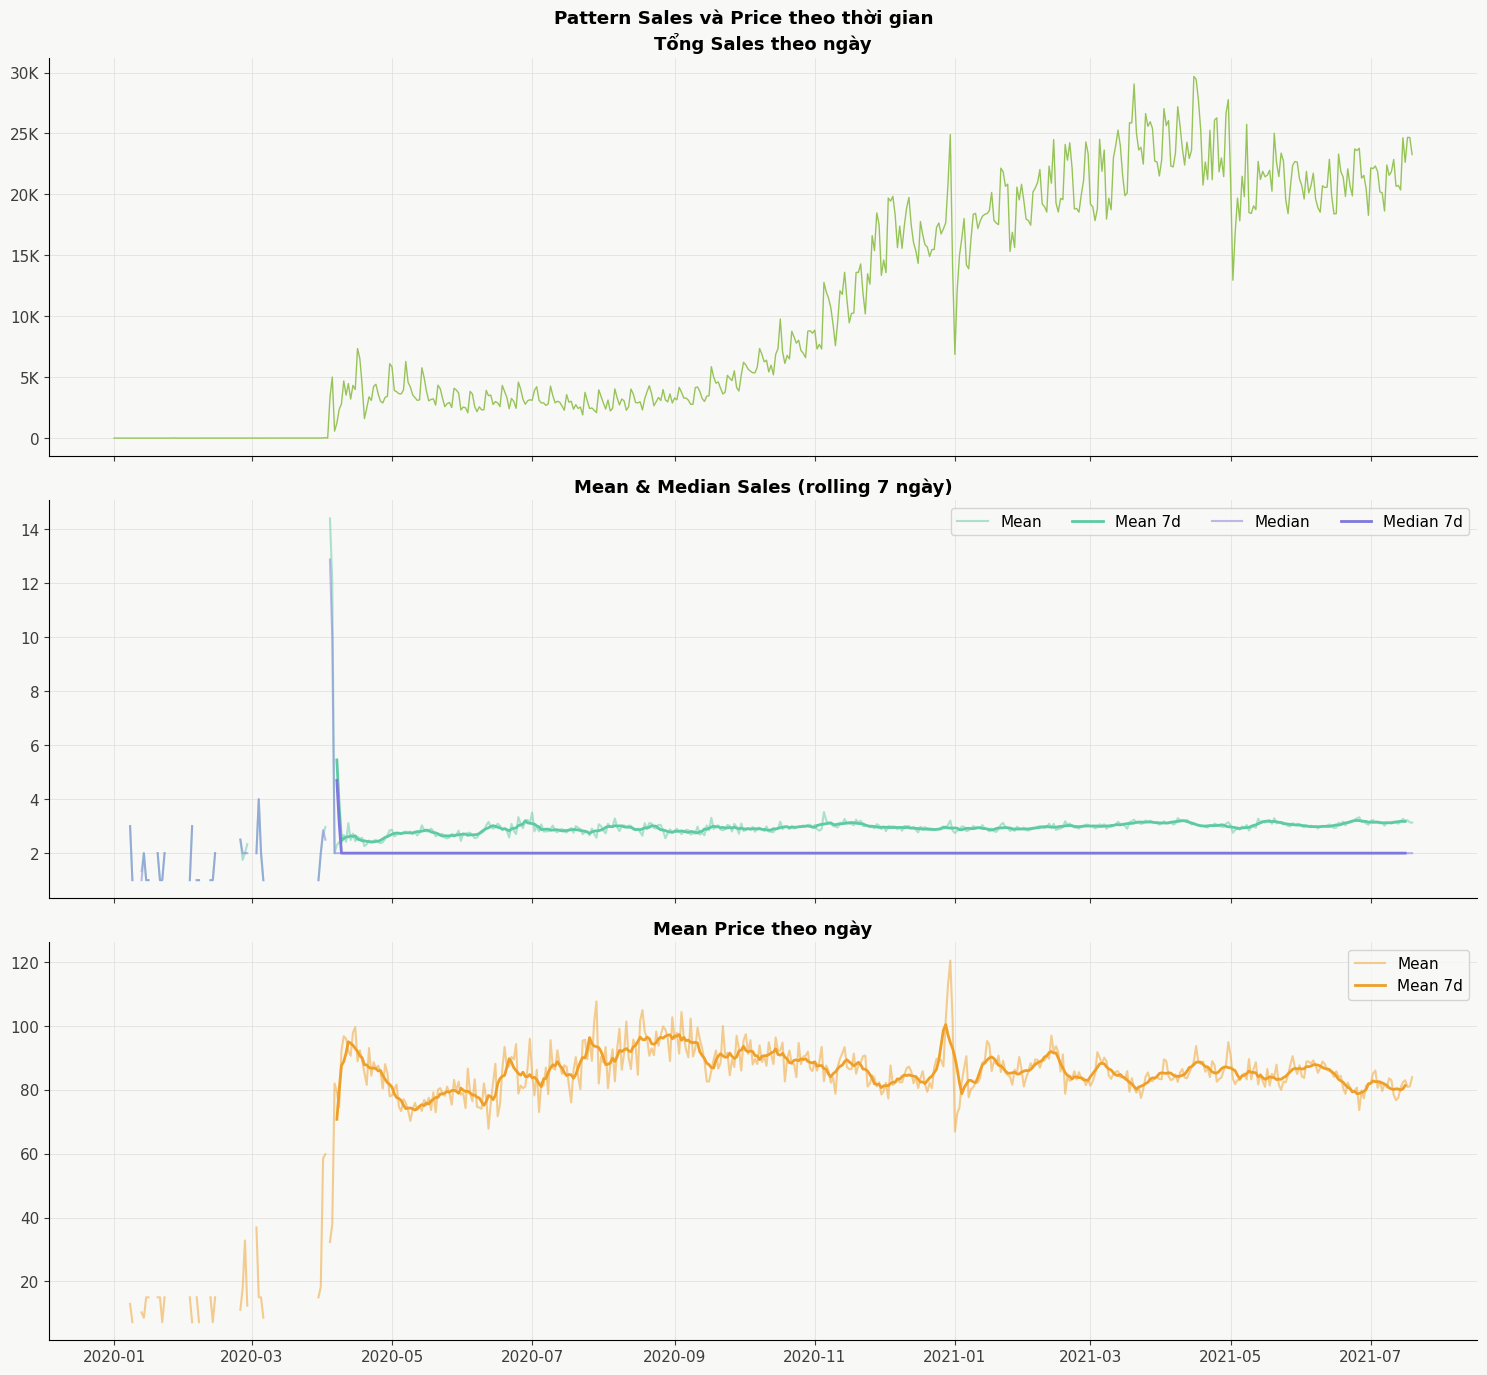

In [28]:
# 3. Pattern sales & price theo thời gian
daily = train_df.groupby('date').agg({
    'sales': ['mean', 'median', 'sum'],
    'price': ['mean', 'median']
}).reset_index()
daily.columns = ['date', 'sales_mean', 'sales_median', 'sales_sum', 'price_mean', 'price_median']

daily['sales_mean_7d'] = daily['sales_mean'].rolling(7, center=True).mean()
daily['sales_median_7d'] = daily['sales_median'].rolling(7, center=True).mean()
daily['price_mean_7d'] = daily['price_mean'].rolling(7, center=True).mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=True)
fig.suptitle('Pattern Sales và Price theo thời gian', fontweight='bold', y=0.98)

# Tổng sales
axes[0].plot(daily['date'], daily['sales_sum'], color=GREEN, linewidth=1)
axes[0].set_title('Tổng Sales theo ngày')
axes[0].yaxis.set_major_formatter(FuncFormatter(fmt_millions))

# Mean & Median sales
axes[1].plot(daily['date'], daily['sales_mean'], color=TEAL, alpha=0.5, label='Mean')
axes[1].plot(daily['date'], daily['sales_mean_7d'], color=TEAL, linewidth=2, label='Mean 7d')
axes[1].plot(daily['date'], daily['sales_median'], color=PURPLE, alpha=0.5, label='Median')
axes[1].plot(daily['date'], daily['sales_median_7d'], color=PURPLE, linewidth=2, label='Median 7d')
axes[1].set_title('Mean & Median Sales (rolling 7 ngày)')
axes[1].legend(ncol=4)

# Price
axes[2].plot(daily['date'], daily['price_mean'], color=AMBER, alpha=0.5, label='Mean')
axes[2].plot(daily['date'], daily['price_mean_7d'], color=AMBER, linewidth=2, label='Mean 7d')
axes[2].set_title('Mean Price theo ngày')
axes[2].legend()

plt.tight_layout()
plt.show()

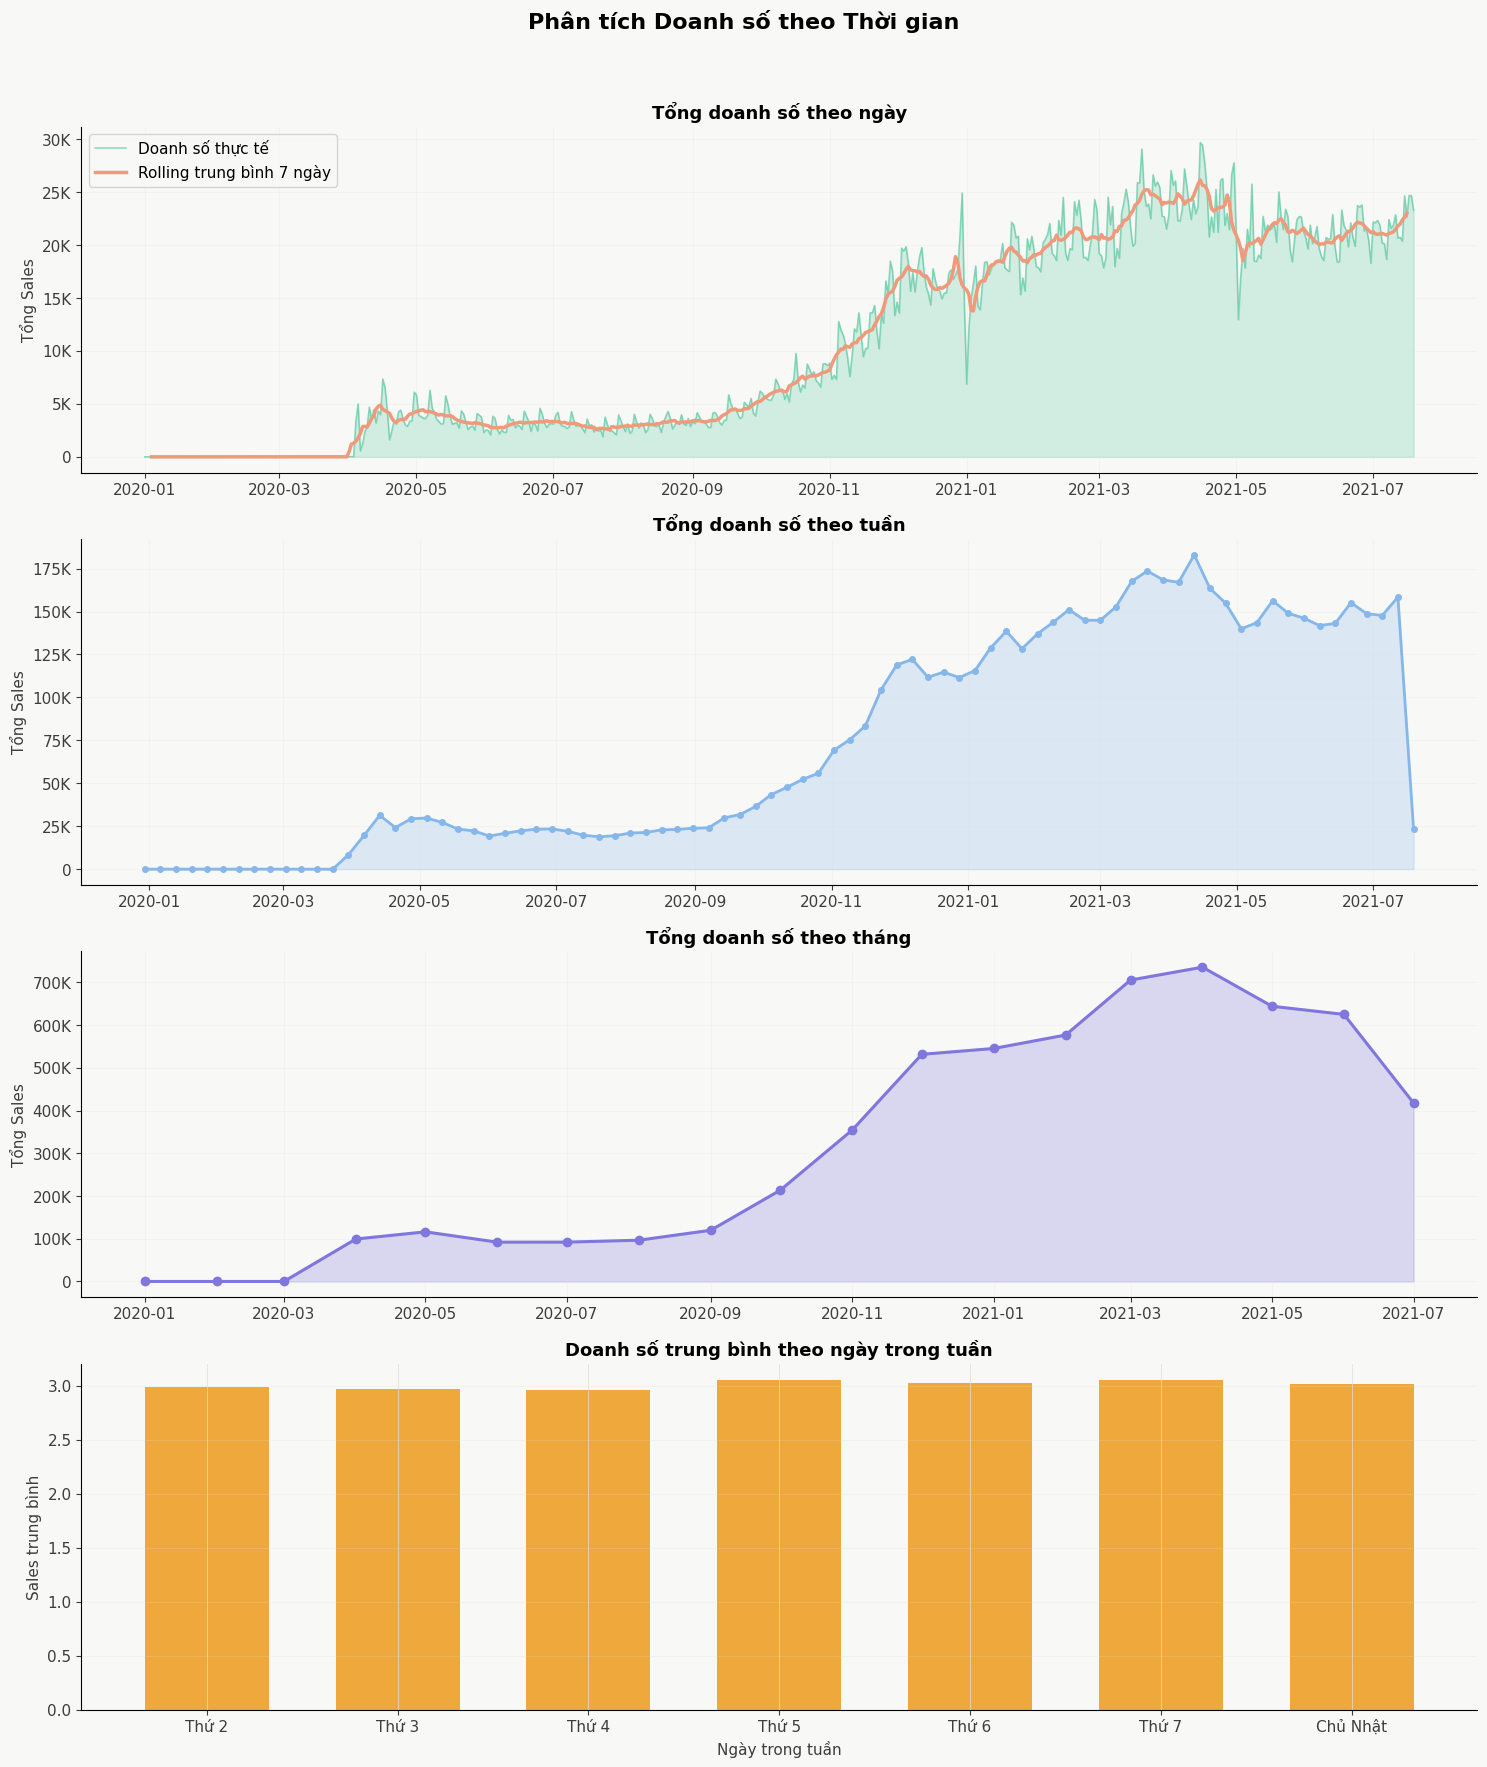


Tổng số ngày quan sát       : 566
Tổng số tuần quan sát       : 82
Doanh số trung bình / ngày   : 10,542
Doanh số trung bình / tuần   : 72,764
Doanh số cao nhất trong ngày : 29,680
Doanh số cao nhất trong tuần : 182,975


In [29]:
# PHÂN TÍCH THEO THỜI GIAN 

# ── 1. Doanh số theo NGÀY ───────────────────────────────────────────────
daily = (train_df.groupby('date')['sales']
         .sum()
         .reset_index())

daily['sales_7d'] = daily['sales'].rolling(window=7, center=True).mean()

# ── 2. Doanh số theo TUẦN ───────────────────────────────────────────────
weekly = (train_df.groupby(train_df['date'].dt.to_period('W'))['sales']
          .sum()
          .reset_index())
weekly['date'] = weekly['date'].dt.start_time

# ── 3. Doanh số theo THÁNG ──────────────────────────────────────────────
monthly = (train_df.groupby(train_df['date'].dt.to_period('M'))['sales']
           .sum()
           .reset_index())
monthly['date'] = monthly['date'].dt.start_time

# ── 4. Doanh số trung bình theo NGÀY TRONG TUẦN ─────────────────────────
dow_sales = train_df.groupby('dow')['sales'].mean()

# ── Vẽ 4 biểu đồ ────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=False)
fig.suptitle('Phân tích Doanh số theo Thời gian', fontweight='bold', fontsize=16, y=0.98)

# 1. Biểu đồ theo NGÀY (có Rolling 7 ngày)
axes[0].plot(daily['date'], daily['sales'], 
             color=TEAL, linewidth=1.1, alpha=0.7, label='Doanh số thực tế')
axes[0].plot(daily['date'], daily['sales_7d'], 
             color=CORAL, linewidth=2.5, label='Rolling trung bình 7 ngày')
axes[0].fill_between(daily['date'], daily['sales'], color=TEAL, alpha=0.25)

axes[0].set_title('Tổng doanh số theo ngày')
axes[0].set_ylabel('Tổng Sales')
axes[0].yaxis.set_major_formatter(FuncFormatter(fmt_millions))
axes[0].legend(framealpha=0.8)
axes[0].grid(True, alpha=0.3)

# 2. Biểu đồ theo TUẦN
axes[1].plot(weekly['date'], weekly['sales'], 
             color=BLUE, linewidth=2.0, marker='o', markersize=4)
axes[1].fill_between(weekly['date'], weekly['sales'], color=BLUE, alpha=0.25)

axes[1].set_title('Tổng doanh số theo tuần')
axes[1].set_ylabel('Tổng Sales')
axes[1].yaxis.set_major_formatter(FuncFormatter(fmt_millions))
axes[1].grid(True, alpha=0.3)

# 3. Biểu đồ theo THÁNG
axes[2].plot(monthly['date'], monthly['sales'], 
             color=PURPLE, linewidth=2.2, marker='o', markersize=6)
axes[2].fill_between(monthly['date'], monthly['sales'], color=PURPLE, alpha=0.25)

axes[2].set_title('Tổng doanh số theo tháng')
axes[2].set_ylabel('Tổng Sales')
axes[2].yaxis.set_major_formatter(FuncFormatter(fmt_millions))
axes[2].grid(True, alpha=0.3)

# 4. Biểu đồ theo NGÀY TRONG TUẦN
axes[3].bar(range(7), dow_sales.values, color=AMBER, width=0.65, alpha=0.9)
axes[3].set_title('Doanh số trung bình theo ngày trong tuần')
axes[3].set_ylabel('Sales trung bình')
axes[3].set_xlabel('Ngày trong tuần')
axes[3].set_xticks(range(7))
axes[3].set_xticklabels(['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật'])
axes[3].grid(True, alpha=0.3, axis='y')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# ====================== THỐNG KÊ TÓM TẮT ======================
print(f"\nTổng số ngày quan sát       : {daily['date'].nunique()}")
print(f"Tổng số tuần quan sát       : {weekly.shape[0]}")
print(f"Doanh số trung bình / ngày   : {daily['sales'].mean():,.0f}")
print(f"Doanh số trung bình / tuần   : {weekly['sales'].mean():,.0f}")
print(f"Doanh số cao nhất trong ngày : {daily['sales'].max():,.0f}")
print(f"Doanh số cao nhất trong tuần : {weekly['sales'].max():,.0f}")

**Nhận xét:**
- Tổng sales có xu hướng tăng rõ rệt theo thời gian nhưng giao động khá mạnh.
- Mean và median rooling 7d khá ổn định.
- Doanh số không quá chênh lệch theo các ngày trong tuần.
- Mean price giao động phức tạp nhưng không quá lớn, khi rooling khá ổn định.

**Gợi ý:**
- Do phạm vi quan sát chỉ hơn 1 năm nên không thể nắm bắt rõ tính mùa vụ của dữ liệu, tuy nhiên các time features như week of year, month có thể có kết quả.
- Nên tạo rolling features để làm mượt tín hiệu đầu vào, và dùng nó để điền khuyết dữ liệu.

In [30]:
del train_df, df, weekly, sales_nonzero, price_valid, sales_clipped, price_clipped
gc.collect()

36835

# EDA liên table
Trước khi tiến hành kết nối các bảng, ta cần ép kiểu các thuộc tính (downcast) để giảm khối lượng dữ liệu cần xử lý, drop các cột không cần thiết, đồng thời với train_final thực hiện lấy samples trong khoảng giữa từ 07/2020 - 01/2021.
- **geo_df:**
  - geoCluster -> int16
  - cityId -> int8
- **sku_final:**
  - SKU: int32
  - productCategoryId, productTypeId, brandId, trademark, countryOfOrigin -> int16
  - commodity_group, lagerUnitTypeId -> category
  - lagerUnitQuantity -> float32
  - Drop {}_caption
- **train_final:**
  - geoCluster -> int16
  - SKU -> int32
  - date -> giữ nguyên hoặc chuyển sang int16 cho day diff từ 1/2020
  - price, sales -> float32
- Bảng geo_df có thể là không cần thiết vì chỉ chứa thông tin cửa hàng và thành phố tương ứng. Vì thông tin thành phố có thể không cần thiết, chính cửa hàng mới mang thông tin chính.

In [31]:
def downcast(df):
    for col in df.columns:
        if pd.api.types.is_integer_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast='integer')
        elif pd.api.types.is_float_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], downcast='float')
    return df

In [32]:
# geo_params
geo_df = Dataset.Tabular.from_delimited_files(path=(datastore, "geo_params.csv")).to_pandas_dataframe()
print("geo_df trước khi optimize:")
print(geo_df.info(memory_usage='deep'))

geo_df['geoCluster'] = geo_df['geoCluster'].astype('int16')
geo_df['cityId']     = geo_df['cityId'].astype('int8')

print("===============================================")
print("geo_df sau optimize:")
print(geo_df.info(memory_usage='deep'))

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
geo_df trước khi optimize:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   geoCluster  515 non-null    int64
 1   cityId      515 non-null    int64
dtypes: int64(2)
memory usage: 8.2 KB
None
geo_df sau optimize:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   geoCluster  515 non-null    int16
 1   cityId      515 non-null    int8 
dtypes: int16(1), int8(1)
memory usage: 1.6 KB
None


In [34]:
# sku_final
sku_cols = ['SKU', 'productCategoryId', 'productTypeId', 'brandId', 
            'lagerUnitQuantity', 'lagerUnitTypeId', 'trademark', 
            'countryOfOrigin', 'commodity_group']

sku_df = Dataset.Tabular.from_delimited_files(path=(datastore, "sku_final.csv")).to_pandas_dataframe()
print("sku_df trước khi optimize:")
print(sku_df.info(memory_usage='deep'))
del sku_df

sku_df = Dataset.Tabular.from_delimited_files(path=(datastore, "sku_final.csv")).to_pandas_dataframe()
sku_df['SKU']               = sku_df['SKU'].astype('int32')          
sku_df['productCategoryId'] = sku_df['productCategoryId'].astype('Int16')
sku_df['productTypeId']     = sku_df['productTypeId'].astype('Int16')
sku_df['brandId']           = sku_df['brandId'].astype('Int16')
sku_df['trademark']         = sku_df['trademark'].astype('Int16')
sku_df['countryOfOrigin']   = sku_df['countryOfOrigin'].astype('Int16')

sku_df['commodity_group']   = sku_df['commodity_group'].astype('category')
sku_df['lagerUnitTypeId']   = sku_df['lagerUnitTypeId'].astype('category')

sku_df['lagerUnitQuantity'] = sku_df['lagerUnitQuantity'].astype('float32')

sku_df = downcast(sku_df)

print("===============================================")
print("sku_df sau optimize:")
print(sku_df.info(memory_usage='deep'))

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
sku_df trước khi optimize:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1961 entries, 0 to 1960
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   SKU                          1961 non-null   int64  
 1   productCategoryId            1961 non-null   float64
 2   productCategory_caption_UKR  1807 non-null   object 
 3   productCategory_caption_RU   1961 non-null   object 
 4   productCategory_caption_ENG  1807 non-null   object 
 5   productTypeId                1744 non-null   float64
 6   productType_caption_UKR      1563 non-null   object 
 7   productType_caption_RU       1744 non-null   object 
 8   productType_caption_ENG      1563 non-null   object 
 9   brandId                      1116 non-null   float64
 10

In [35]:
# Train_final
train_cols = ['geoCluster', 'SKU', 'date', 'price', 'sales']

train_df = Dataset.Tabular.from_delimited_files(path=(datastore, "train_final.csv")).to_pandas_dataframe()
print("train_df trước optimize + filter:")
print(train_df.info(memory_usage='deep'))

# Ép kiểu theo yêu cầu
train_df['geoCluster'] = train_df['geoCluster'].astype('int16')
train_df['SKU']        = train_df['SKU'].astype('int16')
train_df['price']      = train_df['price'].astype('float32')
train_df['sales']      = train_df['sales'].astype('float32')

train_df['date'] = train_df['date'].dt.floor('D')   # chỉ giữ ngày

train_df = downcast(train_df)

print("===============================================")
print("train_df sau downcast:")
print(train_df.info(memory_usage='deep'))

# Filter thời gian: 01/07/2020 - 31/01/2021
start_date = pd.to_datetime('2020-07-01')
end_date   = pd.to_datetime('2021-01-31')
train_df = train_df[(train_df['date'] >= start_date) & (train_df['date'] <= end_date)].copy()
print("===============================================")
print("train_df sau filter:")
print(train_df.info(memory_usage='deep'))

{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe'}
{'infer_column_types': 'False', 'activity': 'to_pandas_dataframe', 'activityApp': 'TabularDataset'}
train_df trước optimize + filter:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27956445 entries, 0 to 27956444
Data columns (total 6 columns):
 #   Column      Dtype         
---  ------      -----         
 0   ID          object        
 1   geoCluster  int64         
 2   SKU         int64         
 3   date        datetime64[ns]
 4   price       float64       
 5   sales       float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 2.8 GB
None
train_df sau downcast:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27956445 entries, 0 to 27956444
Data columns (total 6 columns):
 #   Column      Dtype         
---  ------      -----         
 0   ID          object        
 1   geoCluster  int16         
 2   SKU         int16         
 3   date        datetime64[ns]
 4   price     

In [36]:
# Merge sku_df & train_df
df = train_df.merge(sku_df, on='SKU', how='left')

# Chuyển các cột category sau merge
cat_cols = ['commodity_group', 'lagerUnitTypeId']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("\n=== FINAL DATAFRAME SAU MERGE ===")
print(df.info(memory_usage='deep'))
print(f"Shape cuối cùng: {df.shape}")

# Dọn bộ nhớ
del train_df, sku_df, geo_df
gc.collect()


=== FINAL DATAFRAME SAU MERGE ===
<class 'pandas.core.frame.DataFrame'>
Int64Index: 10035593 entries, 0 to 10035592
Data columns (total 25 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   ID                           object        
 1   geoCluster                   int16         
 2   SKU                          int16         
 3   date                         datetime64[ns]
 4   price                        float32       
 5   sales                        float32       
 6   productCategoryId            Int16         
 7   productCategory_caption_UKR  object        
 8   productCategory_caption_RU   object        
 9   productCategory_caption_ENG  object        
 10  productTypeId                Int16         
 11  productType_caption_UKR      object        
 12  productType_caption_RU       object        
 13  productType_caption_ENG      object        
 14  brandId                      Int16         
 15  lagerUnitQua

56

In [37]:
# Kiểm tra missing values sau merge
null_pct = df.isnull().mean() * 100
print("\nTỉ lệ missing values (%):")
print(null_pct[null_pct > 0].sort_values(ascending=False).round(2))


Tỉ lệ missing values (%):
countryOfOrigin_caption        96.41
countryOfOrigin                96.41
brandId                        95.91
trademark                      95.91
sales                          93.39
price                          93.39
productType_caption_UKR        92.45
productType_caption_ENG        92.45
productCategory_caption_ENG    92.45
productCategory_caption_UKR    92.45
productTypeId                  91.94
productType_caption_RU         91.94
lagerUnitQuantity              91.94
lagerUnitTypeId                91.94
lagerUnitType_caption          91.94
productCategory_caption_RU     91.94
productCategoryId              91.94
commodity_group                91.94
commodity_group_caption_UKR    91.94
commodity_group_caption_RU     91.94
commodity_group_caption_ENG    91.94
dtype: float64


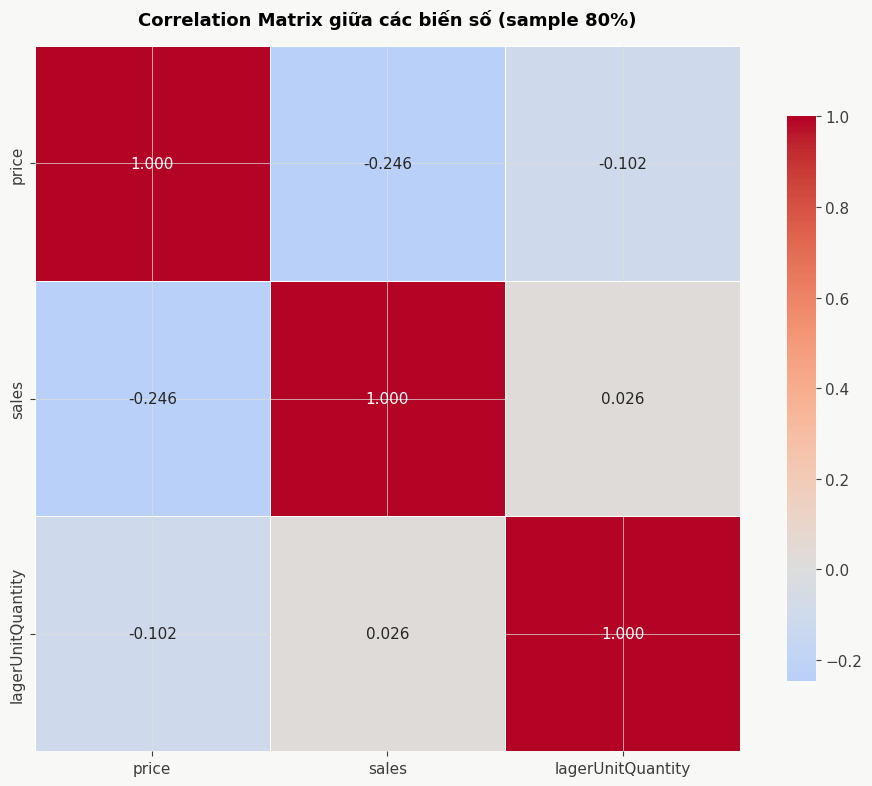

Correlation với cột Sales:
sales                1.000000
lagerUnitQuantity    0.026073
price               -0.245733
Name: sales, dtype: float64


In [38]:
# CORRELATION MATRIX 

num_cols = ['price', 'sales', 'lagerUnitQuantity']

# Sample 5% để tính correlation (đủ ổn định và nhanh)
sample_corr = df[num_cols].sample(frac=0.8, random_state=42)

corr = sample_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix giữa các biến số (sample 80%)', pad=15)
plt.tight_layout()
plt.show()

print("Correlation với cột Sales:")
print(corr['sales'].sort_values(ascending=False))

**Nhận xét:**
- không có tương quan rõ rệt giữa các biến numerical.

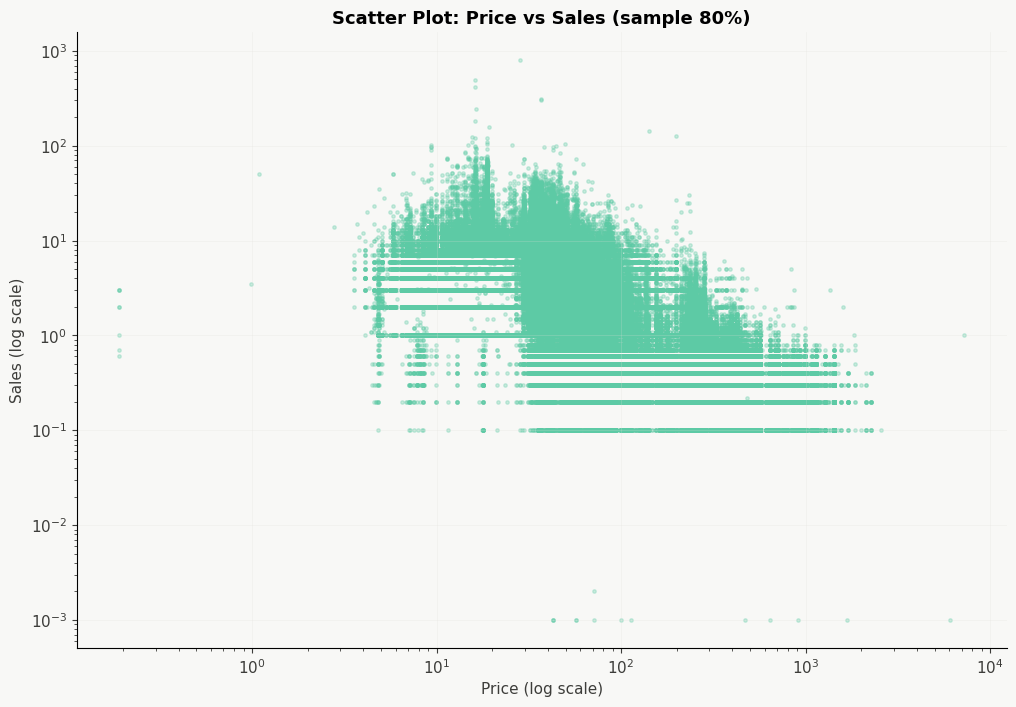

In [39]:
# RELATIONSHIP PRICE vs SALES
sample_scatter = df.sample(frac=0.8, random_state=42)  

plt.figure(figsize=(12, 8))
plt.scatter(sample_scatter['price'], sample_scatter['sales'], 
            alpha=0.3, s=6, color=TEAL)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price (log scale)')
plt.ylabel('Sales (log scale)')
plt.title('Scatter Plot: Price vs Sales (sample 80%)')
plt.grid(True, alpha=0.3)
plt.show()

**Nhận xét**
- Có quan hệ âm nhẹ (r=-0.25) nhưng không đáng kể, variance vẫn rất rộng -> giá cả không quyết định hoàn toàn doanh số.

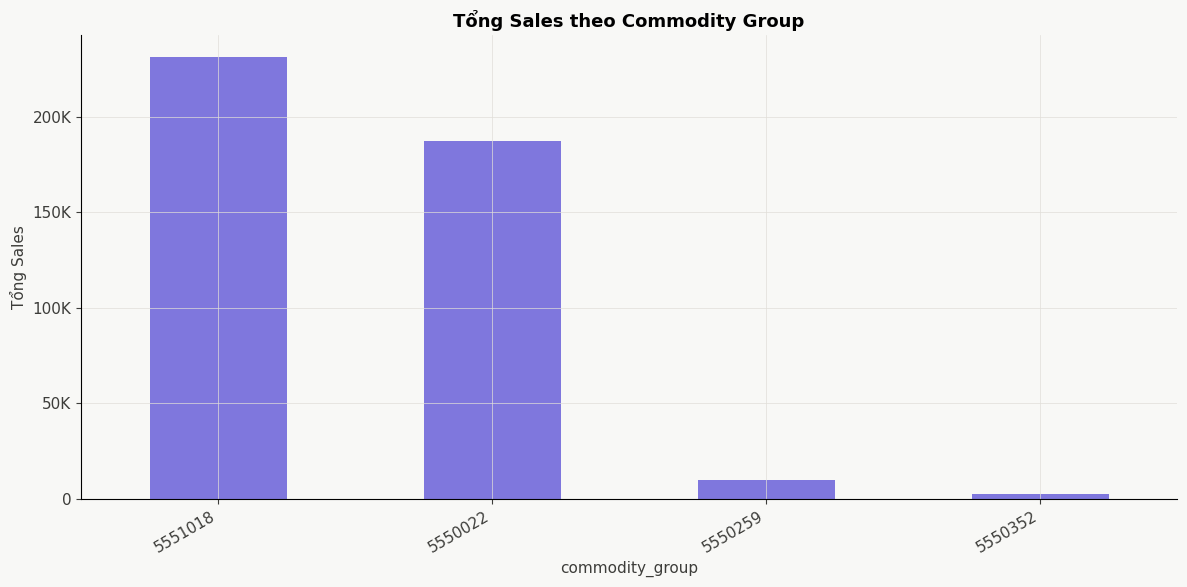

                         total  mean  count
commodity_group                            
5551018          230928.140625  3.67  62878
5550022          187220.000000  5.93  31563
5550259            9740.000000  5.03   1937
5550352            2281.600098  0.61   3765


In [40]:
# SALES THEO COMMODITY GROUP

comm_sales = (df.groupby('commodity_group', observed=True)['sales']
              .agg(total='sum', mean='mean', count='count')
              .sort_values('total', ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))
comm_sales['total'].plot(kind='bar', color=PURPLE, ax=ax)
ax.set_title('Tổng Sales theo Commodity Group')
ax.set_ylabel('Tổng Sales')
ax.yaxis.set_major_formatter(FuncFormatter(fmt_millions))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(comm_sales.round(2))

**Nhận xét:**
Mặc dù có số sản phẩm thuộc nhóm đứng thứ 2, doanh số bán ra của Yogurts lại là nhiều nhất. Điều đáng kể là Tropical Fruits dù có ít sản phẩm nhất nhưng doanh số bán lại đứng thứ 2 cho thấy nhu cầu tiêu dùng vượt trội. Ngược lại Cheese dù nhiều sản phẩm thuộc nhóm nhất nhưng lại có lượng bán ra ít nhất vì thường cheese có thể để rất lâu và kén người mua.

In [41]:
# TOP PRODUCT CATEGORY

top_category = (df.groupby('productCategoryId', observed=True)
                .agg(total_sales=('sales', 'sum'),
                     avg_sales=('sales', 'mean'),
                     sku_count=('SKU', 'nunique'))
                .sort_values('total_sales', ascending=False)
                .head(15))

print(top_category)

                     total_sales  avg_sales  sku_count
productCategoryId                                     
5381               126633.593750   6.068896          1
5834                99338.000000   9.562765          1
5835                56673.000000   3.852423         13
5431                31397.923828   3.397308          1
5434                27692.707031   1.995439          1
5838                23846.000000   4.751146          5
5422                14955.000000   3.584612          1
5425                10694.309570   2.108500          1
5432                10189.904297   2.107529          1
7250                 9740.000000   5.028394          1
5837                 6864.000000   5.215806          8
5428                 3515.000000   2.188668          1
5429                 2664.000000   2.473538          1
5436                 2428.507080   2.044198          1
6456                 2281.600098   0.606003          1


In [42]:
# ====================== 8. SALES THEO GEOCLUSTER (Top) ======================

top_geo = (df.groupby('geoCluster')
           .agg(total_sales=('sales', 'sum'),
                avg_sales=('sales', 'mean'),
                sku_unique=('SKU', 'nunique'),
                row_count=('sales', 'count'))
           .sort_values('total_sales', ascending=False)
           .head(20))

print(top_geo.round(2))

             total_sales  avg_sales  sku_unique  row_count
geoCluster                                                
2054        80092.796875       4.13         585      19403
2735        73741.898438       3.82         677      19288
2043        72099.398438       3.59         706      20082
2049        64472.601562       3.62         682      17798
1935        48469.199219       3.17         680      15301
2022        47593.800781       3.37         660      14113
2149        44698.800781       3.48         599      12853
2021        37478.199219       3.81         501       9837
1991        37090.699219       3.15         584      11765
2056        35564.800781       3.26         594      10915
2542        34191.101562       3.04         624      11231
2031        31866.000000       3.40         491       9366
2023        28230.400391       3.11         530       9063
2069        28043.000000       3.06         616       9156
2240        25611.199219       3.06         526       83

**Nhận xét:**
- Số dòng dữ liệu theo ngày tăng dẫn theo thời gian.
- Vào giai đoạn đầu của quan sát có rất ít sản phẩm và cửa hàng lưu thông tin bán ra. Nhưng càng về sau, càng nhiều dữ liệu được ghi nhận.

**Gợi ý:**
- Có thể bỏ dữ liệu trước tháng 5/2020.

In [44]:
df.columns

Index(['ID', 'geoCluster', 'SKU', 'date', 'price', 'sales',
       'productCategoryId', 'productCategory_caption_UKR',
       'productCategory_caption_RU', 'productCategory_caption_ENG',
       'productTypeId', 'productType_caption_UKR', 'productType_caption_RU',
       'productType_caption_ENG', 'brandId', 'lagerUnitQuantity',
       'lagerUnitTypeId', 'lagerUnitType_caption', 'trademark',
       'countryOfOrigin', 'countryOfOrigin_caption', 'commodity_group',
       'commodity_group_caption_UKR', 'commodity_group_caption_RU',
       'commodity_group_caption_ENG'],
      dtype='object')

# Tổng kết
**ETL:**
- Downcast dữ liệu.
- Drop các cột caption chỉ giữ lại 1 ngôn ngữ cho mỗi loại caption.
- Lưu lại dữ liệu dưới dạng parquet để tối ưu bộ nhớ.

**Tiền xử lý:**
- Drop các cột caption còn lại.
- Drop cột ProductType hoặc điền khuyết theo Category và Commodity.
- Điền khuyết sales và price theo rolling mean 7 day của cùng SKU.
- Để nguyên cột commodity_group và unit_type_id nếu không muốn encode (nhưng đang có tính thứ tự) hoặc encode lại theo one-hot hoặc target.
- Encode categorical_id theo target encoding.
- Thêm các đặc trưng thời gian.
- Xử lý dữ liệu theo chunk để không bị tràn RAM.
- Dùng các mô hình online-learning.
- Hiện tại, merge bảng sku và train toàn bộ sau khi đã thực hiện drop và downcast như mục EDA liên table không bị tràn RAM.